# Beta VAE Mark 3

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import numpy as np
import ad_tools.tools as tools
import matplotlib.pyplot as plt
import sklearn
import awkward as ak 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import vector as vec

## 1. L256 b1e-1

In [5]:
class BetaVAEMark3Encoder(nn.Module):
    """
    Beta VAE Mark 3 Encoder 
    """
    def __init__(self, latent_dim = 7, log_clamping = True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 6, out_channels = 8, kernel_size = 3, padding = (1,0))
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = 3,padding = (1,0))
        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3,padding = (1,0))
        self.pool1 = nn.MaxPool2d(2, return_indices = True)
        self.pool2 = nn.MaxPool2d((5,2), return_indices = True)
        self.pool3 = nn.MaxPool2d((5,2), return_indices = True)
        self.flatten = nn.Flatten(start_dim = 1)
        self.mu = nn.Linear(256, latent_dim)
        self.logvar = nn.Linear(256, latent_dim)
        self.circular_padding = nn.CircularPad2d((1,1,0,0))
        self.log_clamping = log_clamping


    
    def forward(self, input):
        # Convolutional Block 1
        output1 = self.circular_padding(input)
        output2 = self.conv1(output1)
        output3 = F.leaky_relu(output2)
        output4, indices1 = self.pool1(output3)



        # Convolutional Block 2
        output5 = self.circular_padding(output4)
        output6 = self.conv2(output5)
        output7 = F.leaky_relu(output6)
        output8 , indices2 = self.pool2(output7)



        # Convolutional Block 3
        output9 = self.circular_padding(output8)
        output10 = self.conv3(output9)
        output11 = F.leaky_relu(output10)
        output12, indices3 = self.pool3(output11)



        # Latent space mapping
        output13 = self.flatten(output12)
        mu = self.mu(output13)
        logvar = self.logvar(output13)
        if self.log_clamping:
            logvar = torch.clamp(logvar,-5,0)
        
        return mu, logvar,indices1,indices2,indices3

    
class BetaVAEMark3Decoder(nn.Module):
    """
    Beta VAE Mark 3  Decoder.
    """
    def __init__(self, latent_dim = 7):
        super().__init__()
        self.linear = nn.Linear(latent_dim, 256)
    
        self.unpool1 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv1 = nn.ConvTranspose2d(in_channels = 32 , out_channels = 16 ,kernel_size = 3, padding = (1,2))
        


        self.unpool2 = nn.MaxUnpool2d(kernel_size = (5,2))
        self.transconv2 = nn.ConvTranspose2d(in_channels = 16 , out_channels = 8 ,kernel_size = 3, padding = (1,2))
        


        self.unpool3 = nn.MaxUnpool2d(kernel_size = 2)
        self.transconv3 = nn.ConvTranspose2d(in_channels = 8 , out_channels = 6 ,kernel_size = 3, padding = (1,2))        
        self.circular = nn.CircularPad2d((1,1,0,0))
        
    
    def forward(self, latent_vector,indices1, indices2, indices3):
        output1 = self.linear(latent_vector)
        output2 = F.leaky_relu(output1)
        output3 = torch.reshape(output2, shape = (-1,32,1,8))


        
        # Deconvolution Block 1
        output4 = self.unpool1(output3, indices3)
        output5 = self.circular(output4)
        output6 = self.transconv1(output5)
        output7 = F.leaky_relu(output6)



        # Deconvolution Block2
        output8 = self.unpool2(output7, indices2)
        output9 = self.circular(output8)
        output10 = self.transconv2(output9)
        output11 = F.leaky_relu(output10)



        # Deconvolution Block8
        output12 = self.unpool3(output11, indices1)
        output13 = self.circular(output12)
        output14 = self.transconv3(output13)
        output15 = F.relu(output14)
        return output15
    
class BetaVAEMark3(nn.Module):
    """
    Beta VAE Mark 3.
    """

    def __init__(self, latent_dim = 7, log_clamping = True):
        super().__init__()
        self.encoder = BetaVAEMark3Encoder(latent_dim = latent_dim, log_clamping = log_clamping)
        self.decoder = BetaVAEMark3Decoder(latent_dim = latent_dim)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std) 
        return mu + eps * std
    
    def forward(self, input):
        mu, logvar, indices1, indices2, indices3 = self.encoder(input)
        z = self.reparameterise(mu, logvar)
        output = self.decoder(z, indices1, indices2, indices3)
        return output, mu, logvar,z

### PCA Component Analysis of Latent Space

In [56]:
jz0_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/jz0_latent_codes.npy").reshape(49000,256)

In [57]:
pca = PCA()
pca.fit(jz0_latent_codes)
evr = pca.explained_variance_ratio_

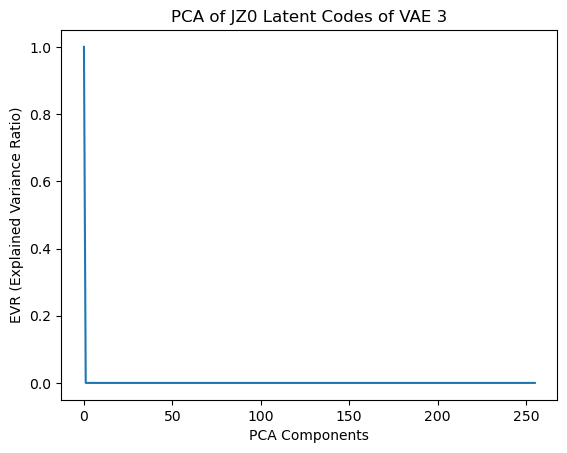

In [58]:
plt.plot(evr)
plt.xlabel("PCA Components")
plt.ylabel("EVR (Explained Variance Ratio)")
plt.title("PCA of JZ0 Latent Codes of VAE 3")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/notebooks/JZ0_PCA_VAE3.png")

### $\chi^2$ distributions.

In [72]:
jz0_latent_codes

array([[ 0.18259563, -0.61849785,  0.40103602, ..., -0.27421936,
        -3.6640549 ,  0.46353155],
       [ 0.42564464, -0.6565333 , -0.11787105, ..., -0.32616192,
        -1.4953877 , -1.0787246 ],
       [ 0.65274173, -0.07706005,  0.8336028 , ...,  0.32644138,
         0.00617494,  0.648049  ],
       ...,
       [ 0.65177435,  0.46161783,  0.18496172, ..., -1.2888737 ,
        -1.0197176 , -0.02818969],
       [ 1.4248403 ,  0.6275415 ,  0.66701865, ..., -0.7794193 ,
         0.16321817,  1.4452357 ],
       [ 0.76376295,  0.73141336, -0.43722516, ..., -1.2598631 ,
        -3.2563517 ,  1.3076673 ]], dtype=float32)

In [64]:
jz0_chi = np.sum(jz0_latent_codes**2, axis = 1)
chi = np.random.chisquare(256, 49000)

In [79]:
jz0_chi.max()

77336090000000.0

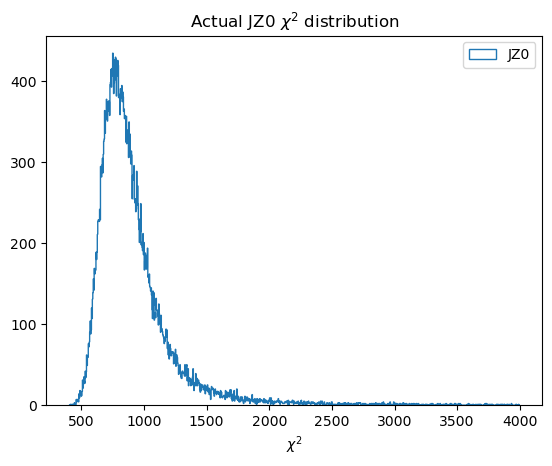

In [93]:
plt.hist(jz0_chi, bins = 1000,range= (400,4000) ,label = "JZ0", histtype= "step")
plt.legend()
plt.xlabel("$\chi^2$")
plt.title("Actual JZ0 $\chi^2$ distribution")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/notebooks/JZ0_VAE3_Actual_Chi.png")


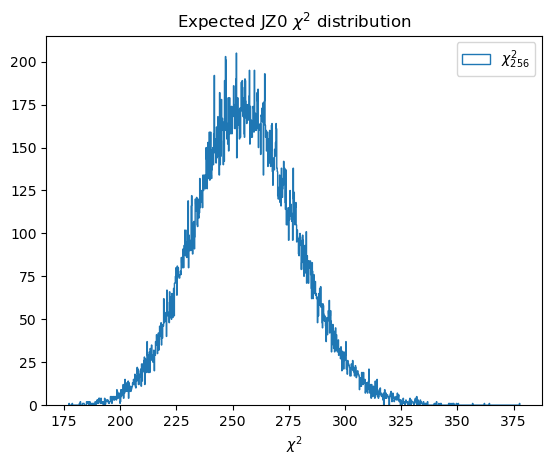

In [94]:
plt.hist(chi, bins = 1000, histtype = "step", label = "$\chi^2_{256}$")
plt.legend()
plt.xlabel("$\chi^2$")
plt.title("Expected JZ0 $\chi^2$ distribution")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/notebooks/JZ0_VAE3_Expected_Chi.png")

### t-SNE

In [19]:
ggf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/ggF_latent_codes.npy").reshape(50000,256)
hs_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/hs_latent_codes2.npy").reshape(10000,256)
vbf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/vbf_latent_codes2.npy").reshape(10000,256)

In [20]:
scaler = StandardScaler()
tsne = TSNE(n_components=2, random_state=42, perplexity=50)

In [21]:
ggf_scaled = scaler.fit_transform(ggf_latent_codes[:10000])
ggf_tsne = tsne.fit_transform(ggf_scaled)
jz0_scaled = scaler.fit_transform(jz0_latent_codes[:10000])
jz0_tsne = tsne.fit_transform(jz0_scaled)
vbf_scaled = scaler.fit_transform(vbf_latent_codes[:10000])
vbf_tsne = tsne.fit_transform(vbf_latent_codes)
hs_scaled = scaler.fit_transform(hs_latent_codes[:10000])
hs_tsne = tsne.fit_transform(hs_latent_codes)

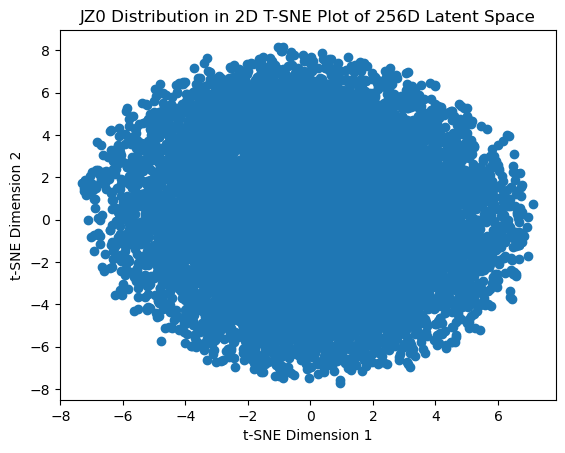

In [23]:
plt.scatter(jz0_tsne[:,0],jz0_tsne[:,1])
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("JZ0 Distribution in 2D T-SNE Plot of 256D Latent Space")
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/tSNE_latentspace_jz0")

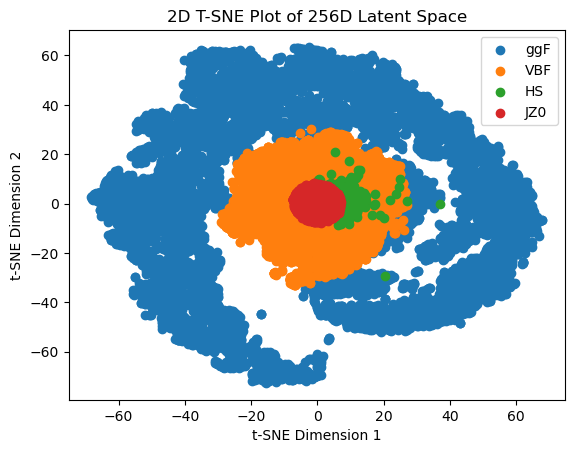

In [24]:
plt.scatter(ggf_tsne[:,0],ggf_tsne[:,1], label = "ggF")
plt.scatter(vbf_tsne[:,0],vbf_tsne[:,1], label = "VBF")
plt.scatter(hs_latent_codes[:,0],hs_latent_codes[:,1], label = "HS")
plt.scatter(jz0_tsne[:,0],jz0_tsne[:,1], label = "JZ0")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("2D T-SNE Plot of 256D Latent Space")
plt.legend()
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/tSNE_latentspace")

### Histograms

In [40]:
fig1,ax1 = plt.subplots(2,2, figsize = (20,15))
ax1[0,0].set_title("2D rep of 256D Latent space encodings \n of events")
ax1[0,0].hist2d(jz0_latent_codes[:,0],jz0_latent_codes[:,1], label = "JZ0", bins = 1000)
ax1[0,0].set_xlabel("Dim 1")
ax1[0,0].set_ylabel("Dim 2")
ax1[0,0].set_xlim(-6,6)
ax1[0,0].set_ylim(-6,6)


ax1[0,1].set_title("2D rep of 256D Latent space encodings \n of events")
ax1[0,1].hist2d(jz0_latent_codes[:,2],jz0_latent_codes[:,3], label = "JZ0", bins = 1000)
ax1[0,1].set_xlabel("Dim 3")
ax1[0,1].set_ylabel("Dim 4")

ax1[1,0].set_title("2D rep of 256D Latent space encodings \n of events")
ax1[1,0].hist2d(jz0_latent_codes[:,4],jz0_latent_codes[:,5], label = "JZ0", bins = 1000)
ax1[1,0].set_xlabel("Dim 5")
ax1[1,0].set_ylabel("Dim 6")

ax1[1,1].set_title("2D rep of 256D Latent space encodings \n of events")
ax1[1,1].hist2d(jz0_latent_codes[:,6],jz0_latent_codes[:,7], label = "JZ0", bins = 1000)
ax1[1,1].set_xlabel("Dim 7")
ax1[1,1].set_ylabel("Dim 8")

fig1.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/jz0_only_latent_space_hist.png")

KeyboardInterrupt: 

Text(0, 0.5, 'Dim 2')

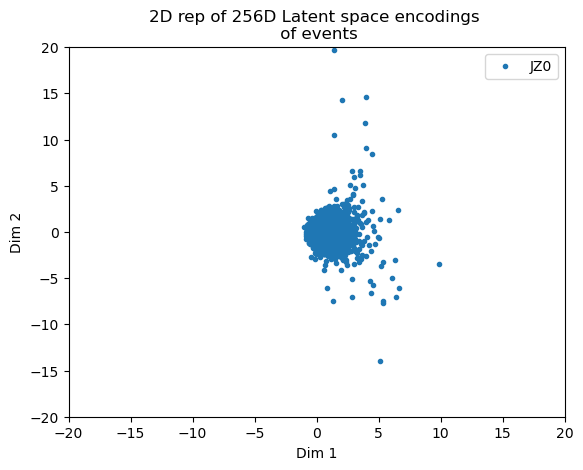

In [31]:
plt.title("2D rep of 256D Latent space encodings \n of events")
plt.plot(jz0_latent_codes[:,0],jz0_latent_codes[:,1],"." , label = "JZ0")
plt.legend()
plt.xlim(-20,20)
plt.ylim(-20,20)
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

Text(0, 0.5, 'Dim 4')

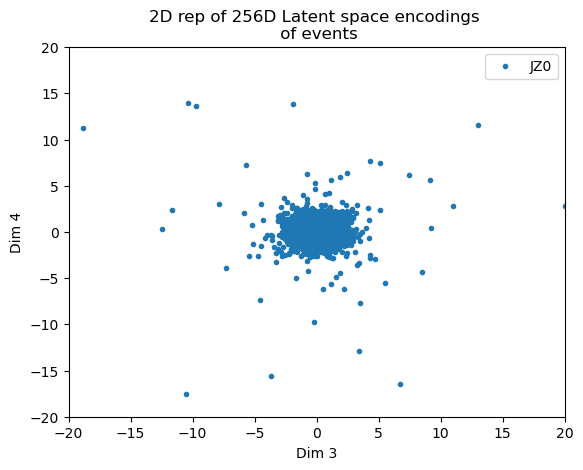

In [36]:
plt.title("2D rep of 256D Latent space encodings \n of events")
plt.plot(jz0_latent_codes[:,2],jz0_latent_codes[:,3],"." , label = "JZ0")
plt.legend()
plt.xlim(-20,20)
plt.ylim(-20,20)
plt.xlabel("Dim 3")
plt.ylabel("Dim 4")

Text(0, 0.5, 'Dim 4')

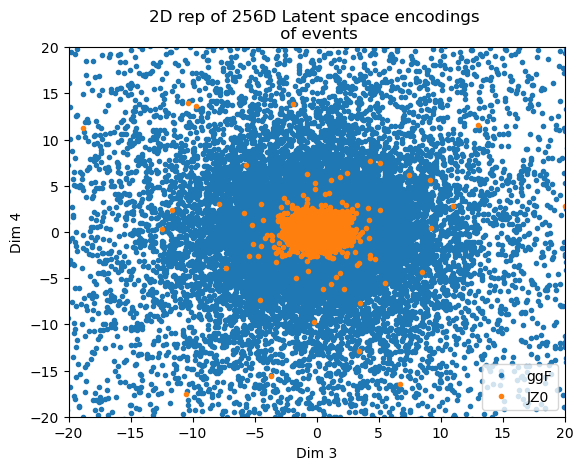

In [27]:
plt.title("2D rep of 256D Latent space encodings \n of events")
plt.plot(ggf_latent_codes[:,2],ggf_latent_codes[:,3],".", label = "ggF" )
plt.plot(jz0_latent_codes[:,2],jz0_latent_codes[:,3],"." , label = "JZ0")
plt.legend()
plt.xlim(-20,20)
plt.ylim(-20,20)
plt.xlabel("Dim 3")
plt.ylabel("Dim 4")

Text(0, 0.5, 'Dim 6')

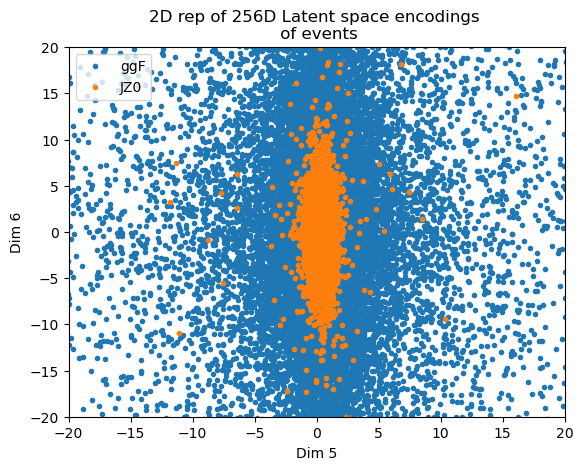

In [24]:
plt.title("2D rep of 256D Latent space encodings \n of events")
plt.plot(ggf_latent_codes[:,8],ggf_latent_codes[:,9],".", label = "ggF" )
plt.plot(jz0_latent_codes[:,8],jz0_latent_codes[:,9],"." , label = "JZ0")
plt.legend()
plt.xlim(-20,20)
plt.ylim(-20,20)
plt.xlabel("Dim 5")
plt.ylabel("Dim 6")

### Losses

In [2]:
jz0_kl_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/testing_losses/jz0_kl_losses.npy")
ggf_kl_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/testing_losses/ggF_kl_losses.npy")
vbf_kl_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/testing_losses/vbf_kl_losses.npy")
hs_kl_losses = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/testing_losses/hs_kl_losses.npy")

In [3]:
kl_cutoff = np.load("data/model_data/BetaVAEMark3/l256_b1/signal_acceptance_rates/KLCutoff.npy")

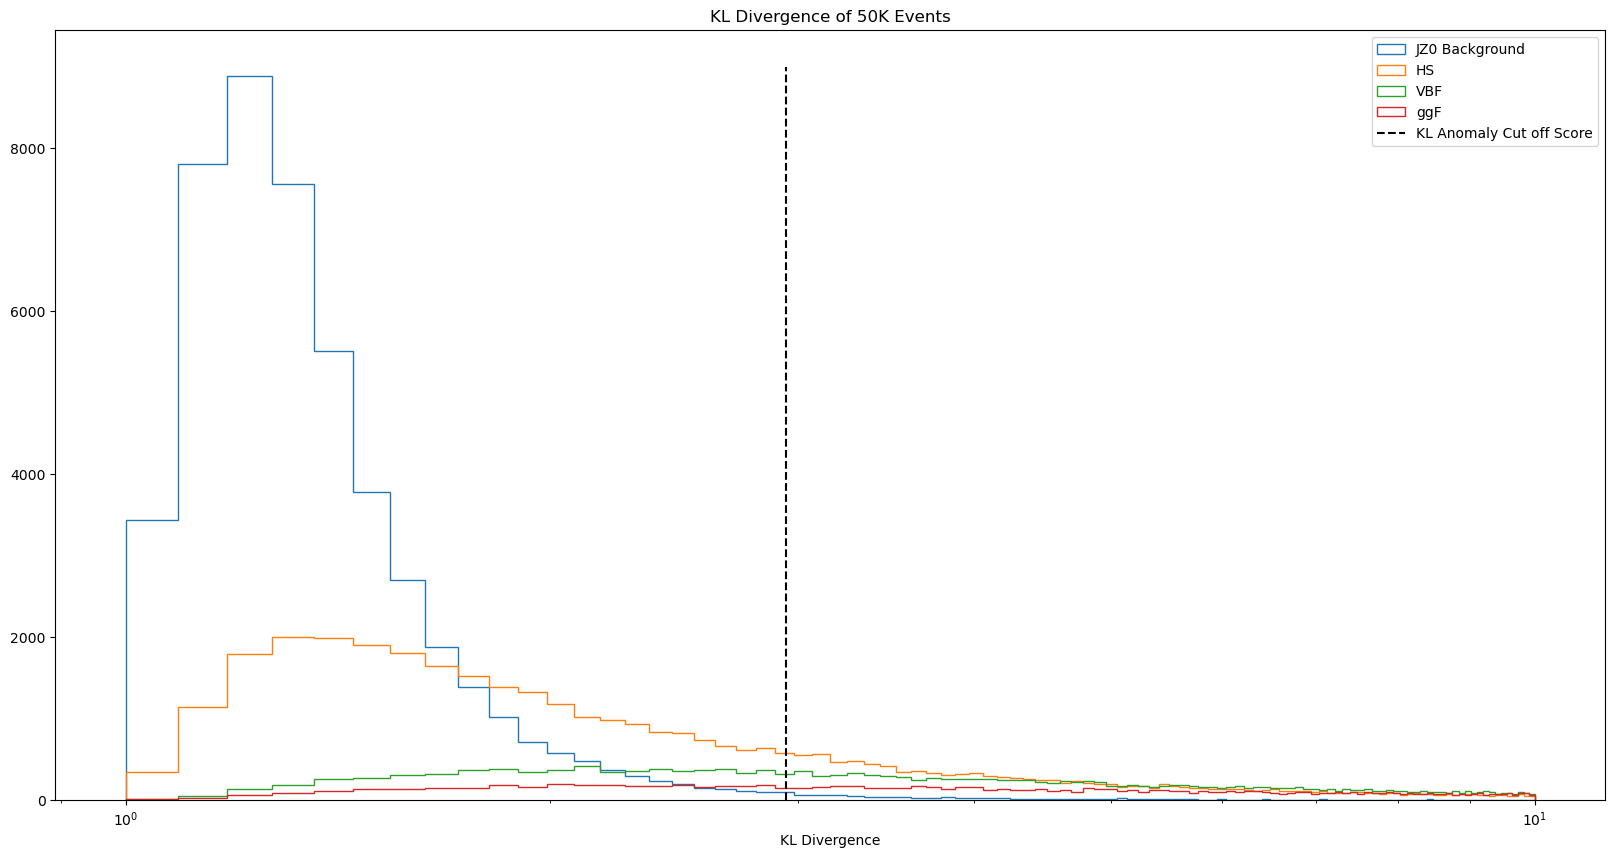

In [9]:
fig2,ax2 = plt.subplots(1,1, figsize = (20,10))
ax2.hist(jz0_kl_losses, bins = 100, range = (1,10), label = "JZ0 Background", histtype= "step")
ax2.hist(hs_kl_losses, bins = 100, range = (1,10), label = "HS", histtype= "step")#
ax2.hist(vbf_kl_losses, bins = 100, range = (1,10), label = "VBF",histtype= "step")
ax2.hist(ggf_kl_losses, bins = 100, range = (1,10), label = "ggF", histtype= "step")
ax2.vlines(kl_cutoff, 0,9000, label = "KL Anomaly Cut off Score", linestyles="dashed", colors = "black")
ax2.set_xscale("log")
ax2.legend()
ax2.set_xlabel("KL Divergence")
ax2.set_title("KL Divergence of 50K Events")
fig2.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/signal_acceptance_rates/kl_divergence_distributions.png")

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,  10.,
         44.,  71., 106., 123., 160., 160., 159., 199., 184., 209., 208.,
        201., 184., 210., 170., 189., 189., 200., 163., 170., 186., 196.,
        173., 163., 162., 185., 171., 155., 187., 170., 133., 137., 149.,
        152., 132., 138., 124., 154., 149., 136., 127., 131., 143., 138.,
        122., 120., 113., 122., 113., 125., 120., 107., 127., 118.,  87.,
         92., 108., 111.,  97.,  94., 101., 108.,  94., 107.,  97.,  90.,
        100., 100.,  98.,  90.,  92.,  81.,  86.,  91.,  88.,  92.,  83.,
         75.,  80.,  78.,  87.,  78.,  82.,  82.,  95.,  86.,  75.,  97.,
         82.]),
 array([ 0.        ,  0.1       ,  0.2       ,  0.30000001,  0.40000001,
         0.5       ,  0.60000002,  0.69999999,  0.80000001,  0.89999998,
         1.        ,  1.10000002,  1.20000005,  1.29999995,  1.39999998,
         1.5       ,  1.60000002,  1.70000005,  1.79999995,  1.89999998,
         2.        ,  2.09

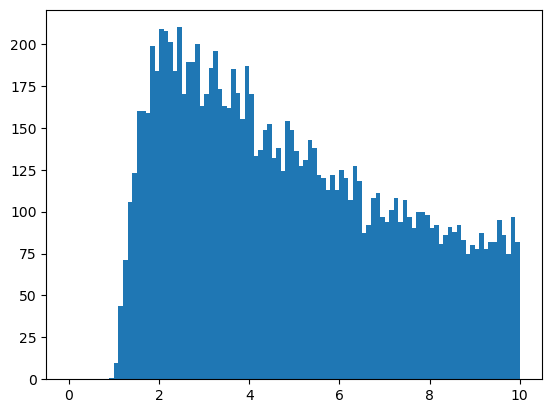

In [47]:
plt.hist(ggf_kl_losses, bins = 100, range = (0,10), label = "ggF")


### Recalculating latent codes, checking reconstructions and other miscellaneous stuff.

In [4]:
model = BetaVAEMark3(latent_dim = 256)
model.load_state_dict(torch.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/weights/BetaVAEMark3_weights_epoch100.pth",map_location=torch.device('cpu')))

<All keys matched successfully>

In [8]:
jz0_rms_energy = 0.0955
ggf_images = ak.to_torch(ak.from_parquet("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/ggF_SM_HH4b.parquet", row_groups = range(10), columns = "cell_towers").cell_towers)
ggf_images = torch.where(torch.sum(ggf_images, dim = 1, keepdim = True) >= 2, ggf_images,0)
ggf_images = ggf_images / jz0_rms_energy
ggf_images = torch.permute(ggf_images, dims = (0,3,1,2))
ggf_images = ggf_images.reshape(-1,6,50,64).to(torch.float32)

vbf_images = ak.to_torch(ak.from_parquet("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/VBF_SM_HH4b.parquet", row_groups = range(10), columns = "cell_towers").cell_towers)
vbf_images = torch.where(torch.sum(vbf_images, dim = 1, keepdim = True) >= 2, vbf_images,0)
vbf_images = vbf_images / jz0_rms_energy
vbf_images = torch.permute(vbf_images, dims = (0,3,1,2))
vbf_images = vbf_images.reshape(-1,6,50,64).to(torch.float32)


hs_images = ak.to_torch(ak.from_parquet("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/HZ_bbvv.parquet", row_groups = range(10), columns = "cell_towers").cell_towers)
hs_images = torch.where(torch.sum(hs_images, dim = 1, keepdim = True) >= 2, hs_images,0)
hs_images = hs_images / jz0_rms_energy
hs_images = torch.permute(hs_images, dims = (0,3,1,2))
hs_images = hs_images.reshape(-1,6,50,64).to(torch.float32)

jz0_images = ak.to_torch(ak.from_parquet("/home/xzcapask/atlas_ad_hllhc/data/atlas_calorimeter_images/JZ0_no_filter.parquet", row_groups = range(200,210), columns = "cell_towers").cell_towers)
jz0_images = torch.where(torch.sum(jz0_images, dim = 1, keepdim = True) >= 2, jz0_images,0)
jz0_images = jz0_images / jz0_rms_energy
jz0_images = torch.permute(jz0_images, dims = (0,3,1,2))
jz0_images = jz0_images.reshape(-1,6,50,64).to(torch.float32)

In [9]:
vbf_latent_codes3 = model(vbf_images)[3].detach().numpy()
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/vbf_latent_codes3", arr = vbf_latent_codes3)

In [10]:
ggf_latent_codes3 = model(ggf_images)[3].detach().numpy()
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/ggf_latent_codes3", arr = ggf_latent_codes3)

In [11]:
jz0_latent_codes3 = model(jz0_images)[3].detach().numpy()
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/jz0_latent_codes3", arr = jz0_latent_codes3)

In [12]:
hs_latent_codes3 = model(hs_images)[3].detach().numpy()
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/hs_latent_codes3", arr = hs_latent_codes3)

In [9]:
np.save(file = "/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/hs_latent_codes2", arr = hs_latent_codes2)

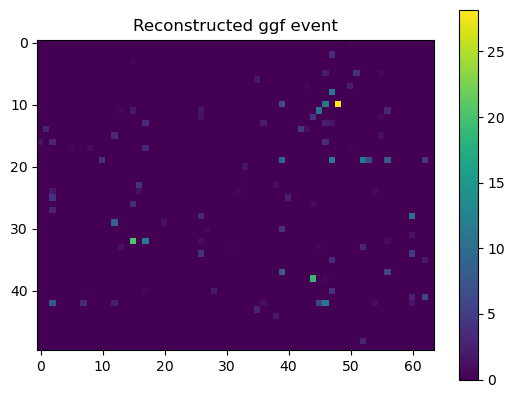

In [110]:
plt.imshow(model(ggf_images)[0][0][0].detach().numpy())
plt.colorbar()
plt.title("Reconstructed ggf event")
plt.savefig("Recon ggf")

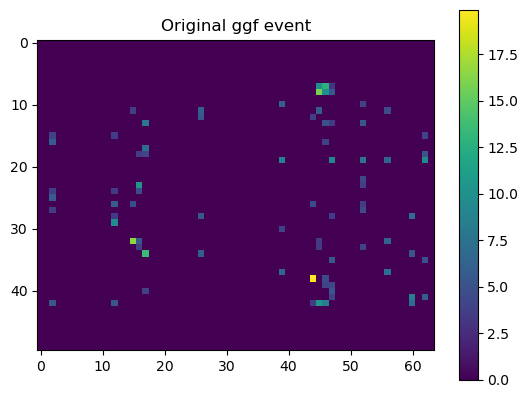

In [112]:
plt.imshow(ggf_images[0][0])
plt.colorbar()
plt.title("Original ggf event")
plt.savefig("Original ggf")

# VAE MARK 3 Best Model Evaluations

In [34]:
np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/KLggFsignalrate.npy")

array(93.92, dtype=float32)

In [35]:
np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/KLvbfsignalrate.npy")

array(86.952, dtype=float32)

In [37]:
np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/KLhssignalrate.npy")

array(48.64, dtype=float32)

## Phi Invariance Evaluation

In [6]:
jz0_kl_pi2 = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/phi_invariance_study/js0pi2kl.npy")
jz0_kl_pi4 = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/phi_invariance_study/jz0pi4kl.npy")
jz0_kl_3pi4 = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/phi_invariance_study/jz03pi4kl.npy")
jz0 = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/testing_losses/jz0_kl_losses.npy")

## Latent Space Evaluation

In [2]:
ggf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/latent_vectors/ggF_latent_codes.npy").reshape(50000,256)
hs_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/latent_vectors/hs_latent_codes.npy").reshape(50000,256)
vbf_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/latent_vectors/vbf_latent_codes.npy").reshape(50000,256)
jz0_latent_codes = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/latent_vectors/jz0_latent_codes.npy").reshape(49000,256)

In [3]:
jz0_chi = np.sum(jz0_latent_codes**2, axis = 1)
chi = np.random.chisquare(256, 49000)

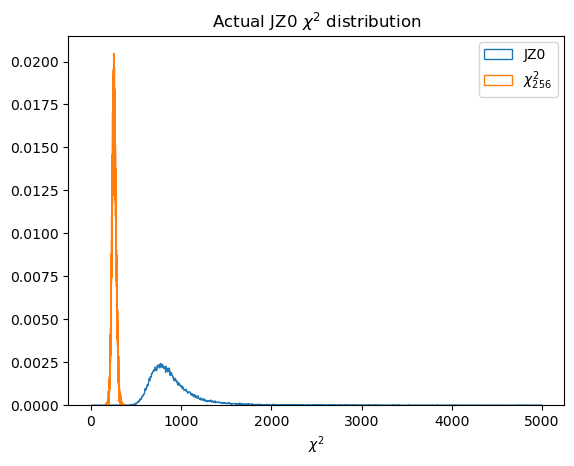

In [39]:
plt.hist(jz0_chi, bins = 1000,
         range= (0,5000),
         label = "JZ0", histtype= "step", density= True)
plt.hist(chi, bins = 1000,
          histtype = "step", label = "$\chi^2_{256}$", density = True)
plt.xlabel("$\chi^2$")
plt.title("Actual JZ0 $\chi^2$ distribution")
plt.legend()



In [39]:
scaler = StandardScaler()
tsne = TSNE(n_components = 2, random_state = 42, perplexity = 50)

In [45]:
ggf_tsne.shape

(10000, 2)

In [44]:
ggf_scaled = scaler.fit_transform(ggf_latent_codes[ggf_latent_codes!= np.inf][:10000].reshape(-1, 10000))
ggf_tsne = tsne.fit_transform(ggf_scaled)
jz0_scaled = scaler.fit_transform(jz0_latent_codes[jz0_latent_codes!= np.inf][:10000].reshape(-1, 10000))
jz0_tsne = tsne.fit_transform(jz0_scaled)
vbf_scaled = scaler.fit_transform(vbf_latent_codes[vbf_latent_codes!= np.inf][:10000].reshape(-1, 10000))
vbf_tsne = tsne.fit_transform(vbf_latent_codes)
hs_scaled = scaler.fit_transform(hs_latent_codes[hs_latent_codes!= np.inf][:10000].reshape(-1, 10000))
hs_tsne = tsne.fit_transform(hs_latent_codes)

ValueError: perplexity (50) must be less than n_samples (1)

In [ ]:
plt.scatter(ggf_tsne[:,0],ggf_tsne[:,1], label = "ggF")
plt.scatter(vbf_tsne[:,0],vbf_tsne[:,1], label = "VBF")
plt.scatter(hs_latent_codes[:,0],hs_latent_codes[:,1], label = "HS")
plt.scatter(jz0_tsne[:,0],jz0_tsne[:,1], label = "JZ0")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("2D T-SNE Plot of 256D Latent Space")
plt.legend()
plt.savefig("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/l256_b1/latent_vectors/tSNE_latentspace")

## Evaluation of Pileup Supression

In [54]:
ggf_signal_acceptance = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/pileup/ggf_pileup_signal_acceptance.npy")
vbf_signal_acceptance = np.load("data/model_data/BetaVAEMark3/pileup/vbf_pileup_signal_acceptance.npy")
hs_signal_acceptance = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/pileup/hs_pileup_signal_acceptance.npy")

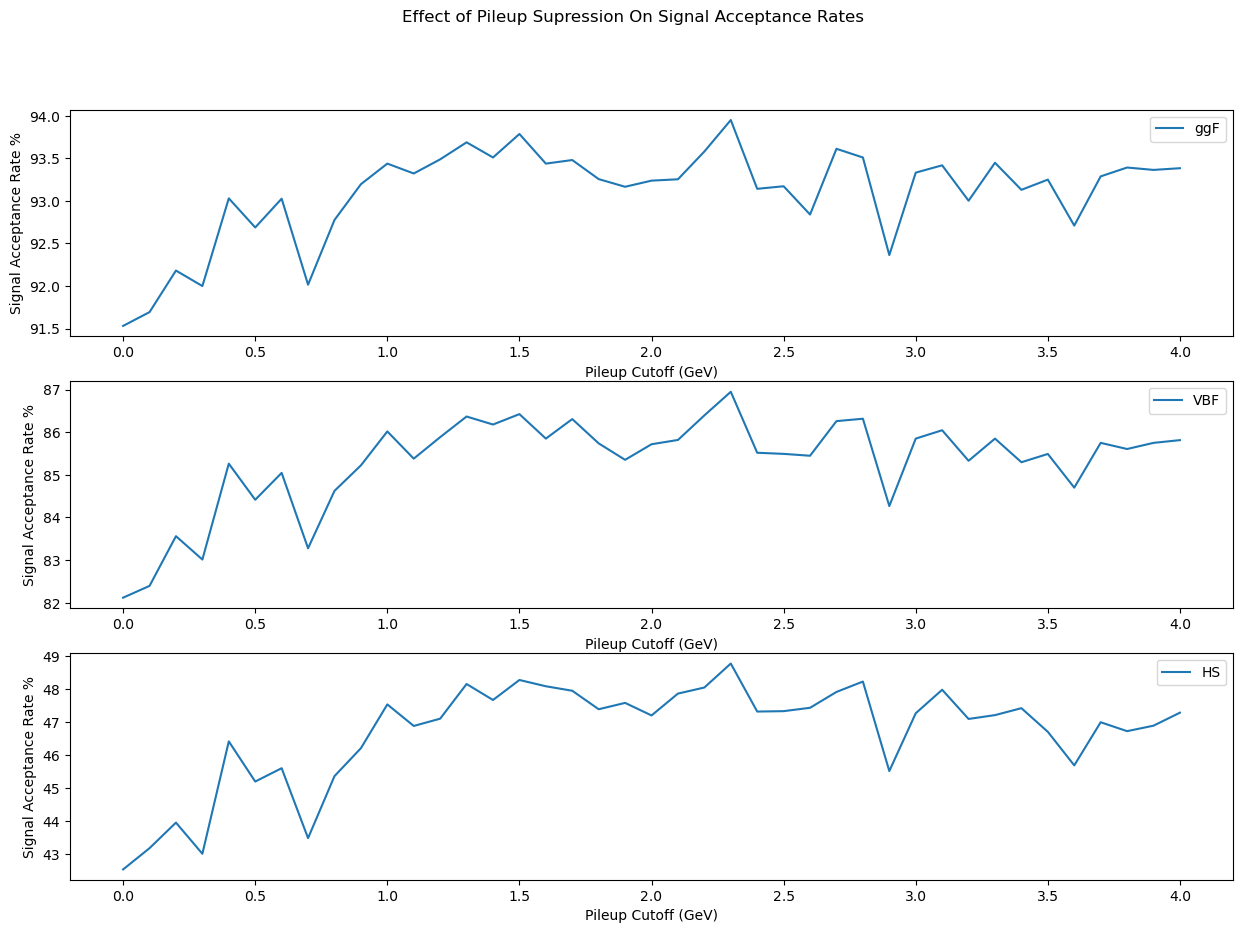

In [55]:
fig1,ax1 = plt.subplots(3,1, figsize = (15,10))
pileup_cut = np.linspace(0,4,41)

fig1.suptitle("Effect of Pileup Supression On Signal Acceptance Rates")

ax1[0].plot(pileup_cut, ggf_signal_acceptance, label = "ggF")
ax1[0].set_xlabel("Pileup Cutoff (GeV)")
ax1[0].set_ylabel("Signal Acceptance Rate %")
ax1[0].legend()

ax1[1].plot(pileup_cut, vbf_signal_acceptance, label = "VBF")
ax1[1].set_xlabel("Pileup Cutoff (GeV)")
ax1[1].set_ylabel("Signal Acceptance Rate %")
ax1[1].legend()

ax1[2].plot(pileup_cut, hs_signal_acceptance, label = "HS")
ax1[2].set_xlabel("Pileup Cutoff (GeV)")
ax1[2].set_ylabel("Signal Acceptance Rate %")
ax1[2].legend()

fig1.savefig("pileup.png")

## Evaluation of Combining Layers

In [24]:
ggf_signal_acceptance = [94.3499984741211,94.05400085449219,92.61199951171875,93.26399993896484,93.90599822998047,93.62999725341797]
vbf_signal_acceptance = [87.9939956665039,87.38200378417969,84.43400573730469,85.50399780273438, 86.70800018310547,86.45600128173828]
hs_signal_acceptance = [50.42399597167969,49.608001708984375,45.02799987792969,46.051998138427734,48.92599868774414,48.62799835205078]
layers_combined = [1,2,3,4,5,6]

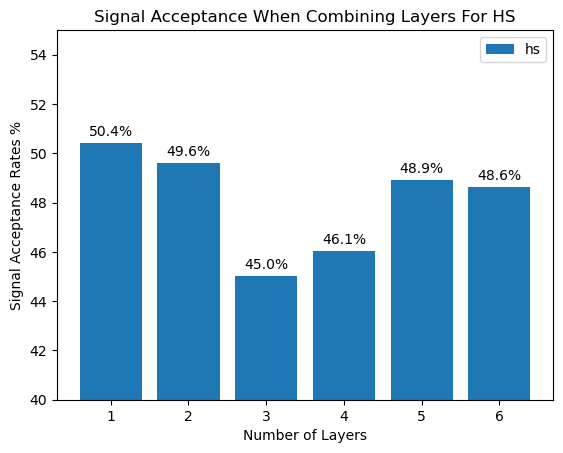

In [29]:
bars = plt.bar(layers_combined, hs_signal_acceptance, label = "hs")
plt.title("Signal Acceptance When Combining Layers For HS")
plt.legend()
plt.ylim(40,55)
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.ylabel("Signal Acceptance Rates %")
plt.xlabel("Number of Layers")
plt.savefig("CombiningLayersHSEvents.png")

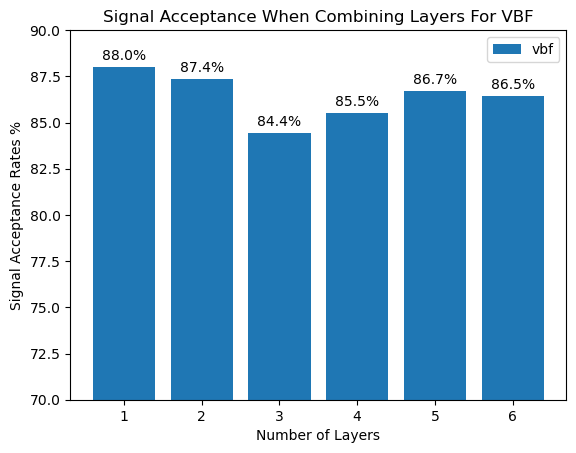

In [33]:
bars = plt.bar(layers_combined, vbf_signal_acceptance, label = "vbf")
plt.title("Signal Acceptance When Combining Layers For VBF")
plt.legend()
plt.ylim(70,90)
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.ylabel("Signal Acceptance Rates %")
plt.xlabel("Number of Layers")
plt.savefig("CombiningLayersvbfEvents.png")

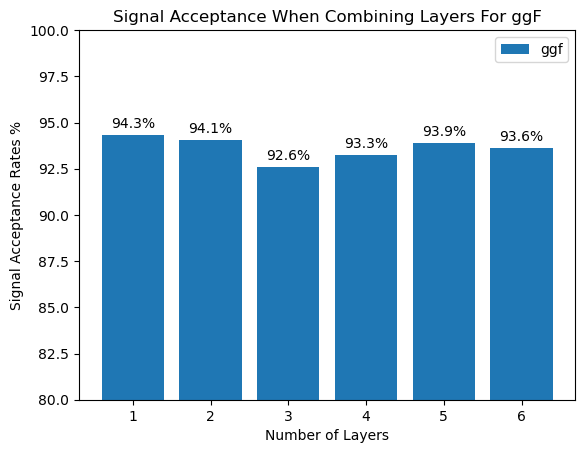

In [32]:
bars = plt.bar(layers_combined, ggf_signal_acceptance, label = "ggf")
plt.title("Signal Acceptance When Combining Layers For ggF")
plt.legend()
plt.ylim(80,100)
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.ylabel("Signal Acceptance Rates %")
plt.xlabel("Number of Layers")
plt.savefig("CombiningLayersggfEvents.png")

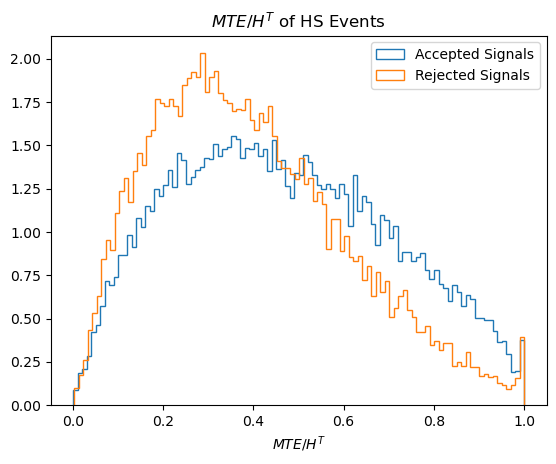

In [52]:
mte_ht_hs_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/combine/1/signal_acceptance_rates/mte_ht_of_registered_hs_signals.npy")
mte_ht_hs_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/combine/1/signal_acceptance_rates/mte_ht_of_unregistered_hs_signals.npy") 
plt.hist(mte_ht_hs_registered, bins = 100, density = True, histtype= "step", label = "Accepted Signals")
plt.hist(mte_ht_hs_unregistered, bins = 100, density = True, histtype= "step", label = "Rejected Signals")
plt.xlabel("$MTE/H^T$")
plt.title("$MTE/H^T$ of HS Events")
plt.legend()
plt.savefig("mte_ht_hs_layers_combined.png")

## MET & $H^T$ vs Anomaly Score

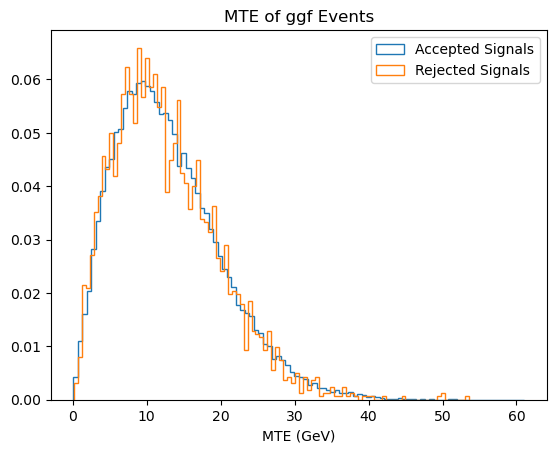

In [39]:
mte_ggf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_of_registered_ggf_signals.npy")
mte_ggf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_of_unregistered_ggf_signals.npy") 
plt.hist(mte_ggf_registered, bins = 100, density = True, histtype= "step", label = "Accepted Signals")
plt.hist(mte_ggf_unregistered, bins = 100, density = True, histtype= "step", label = "Rejected Signals")
plt.xlabel("MTE (GeV)")
plt.title("MTE of ggf Events")
plt.legend()

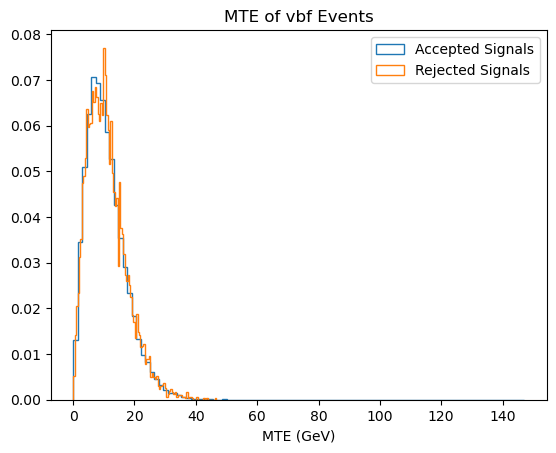

In [40]:
mte_vbf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_of_registered_vbf_signals.npy")
mte_vbf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_of_unregistered_vbf_signals.npy") 
plt.hist(mte_vbf_registered, bins = 100, density = True, histtype= "step", label = "Accepted Signals")
plt.hist(mte_vbf_unregistered, bins = 100, density = True, histtype= "step", label = "Rejected Signals")
plt.xlabel("MTE (GeV)")
plt.title("MTE of vbf Events")
plt.legend()

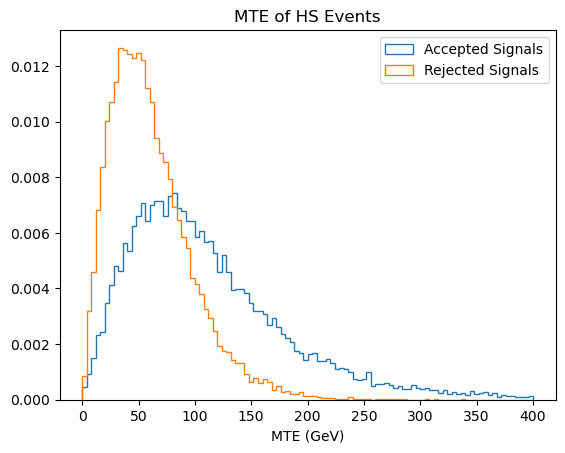

In [42]:
mte_hs_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_of_registered_hs_signals.npy")
mte_hs_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_of_unregistered_hs_signals.npy") 
plt.hist(mte_hs_registered, bins = 100,range = (0,400), density = True, histtype= "step", label = "Accepted Signals")
plt.hist(mte_hs_unregistered, bins = 100,range = (0,400), density = True, histtype= "step", label = "Rejected Signals")
plt.xlabel("MTE (GeV)")
plt.title("MTE of HS Events")
plt.legend()
plt.savefig("MTEofHSEvents.png")

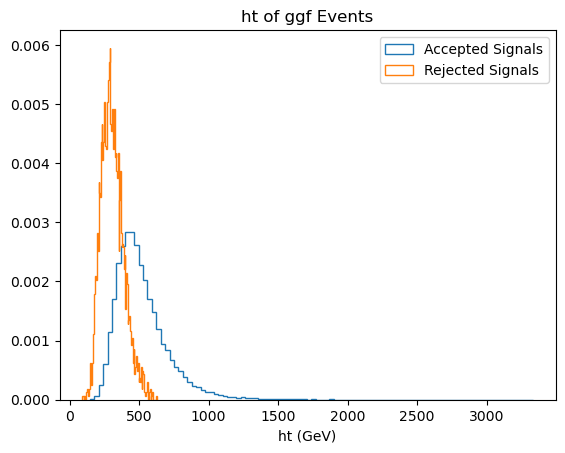

In [243]:
ht_ggf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/ht_of_registered_ggf_signals.npy")
ht_ggf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/ht_of_unregistered_ggf_signals.npy") 
plt.hist(ht_ggf_registered, bins = 100, density = True, histtype= "step", label = "Accepted Signals")
plt.hist(ht_ggf_unregistered, bins = 100, density = True, histtype= "step", label = "Rejected Signals")
plt.xlabel("ht (GeV)")
plt.title("ht of ggf Events")
plt.legend()

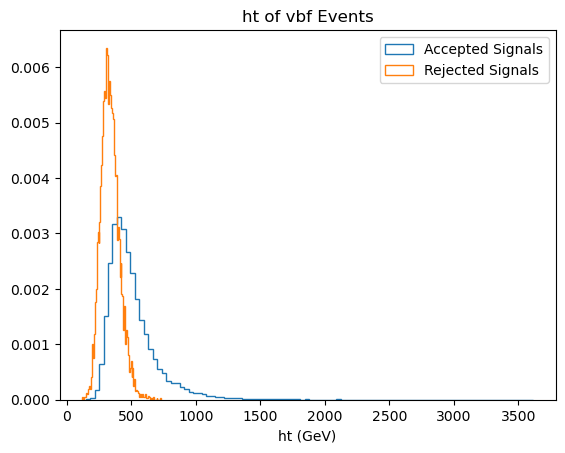

In [244]:
ht_vbf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/ht_of_registered_vbf_signals.npy")
ht_vbf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/ht_of_unregistered_vbf_signals.npy") 
plt.hist(ht_vbf_registered, bins = 100, density = True, histtype= "step", label = "Accepted Signals")
plt.hist(ht_vbf_unregistered, bins = 100, density = True, histtype= "step", label = "Rejected Signals")
plt.xlabel("ht (GeV)")
plt.title("ht of vbf Events")
plt.legend()

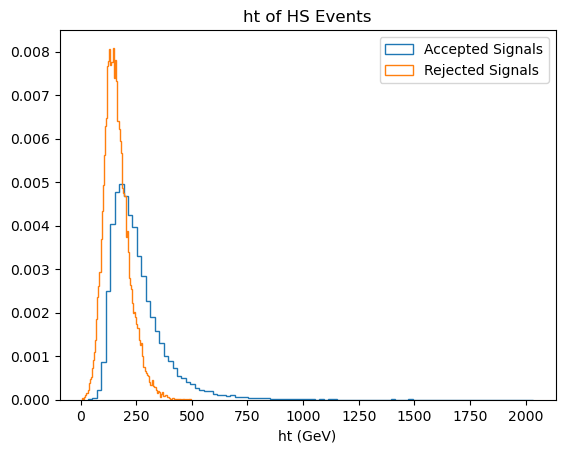

In [245]:
ht_hs_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/ht_of_registered_hs_signals.npy")
ht_hs_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/ht_of_unregistered_hs_signals.npy") 
plt.hist(ht_hs_registered, bins = 100, density = True, histtype= "step", label = "Accepted Signals")
plt.hist(ht_hs_unregistered, bins = 100, density = True, histtype= "step", label = "Rejected Signals")
plt.xlabel("ht (GeV)")
plt.title("ht of HS Events")
plt.legend()

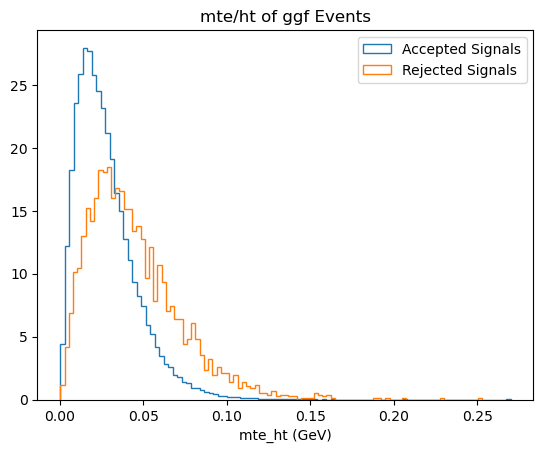

In [247]:
mte_ht_ggf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_ht_of_registered_ggf_signals.npy")
mte_ht_ggf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_ht_of_unregistered_ggf_signals.npy") 
plt.hist(mte_ht_ggf_registered, bins = 100, density = True, histtype= "step", label = "Accepted Signals")
plt.hist(mte_ht_ggf_unregistered, bins = 100, density = True, histtype= "step", label = "Rejected Signals")
plt.xlabel("mte_ht (GeV)")
plt.title("mte/ht of ggf Events")
plt.legend()

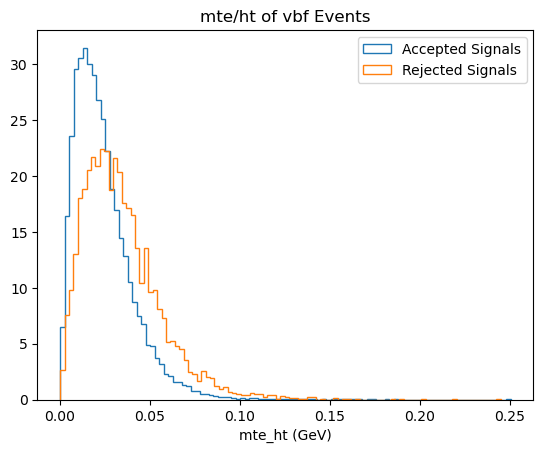

In [248]:
mte_ht_vbf_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_ht_of_registered_vbf_signals.npy")
mte_ht_vbf_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_ht_of_unregistered_vbf_signals.npy") 
plt.hist(mte_ht_vbf_registered, bins = 100, density = True, histtype= "step", label = "Accepted Signals")
plt.hist(mte_ht_vbf_unregistered, bins = 100, density = True, histtype= "step", label = "Rejected Signals")
plt.xlabel("mte_ht (GeV)")
plt.title("mte/ht of vbf Events")
plt.legend()

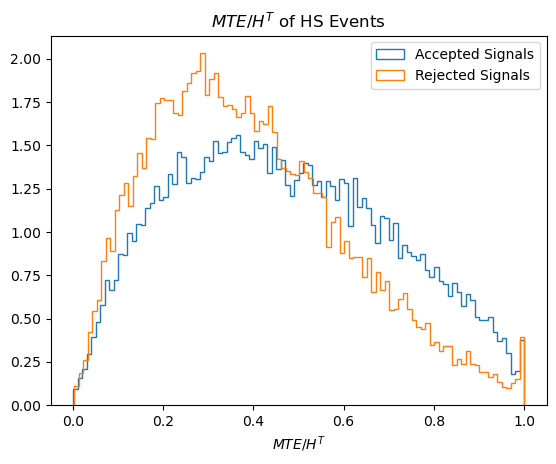

In [51]:
mte_ht_hs_registered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_ht_of_registered_hs_signals.npy")
mte_ht_hs_unregistered = np.load("/home/xzcapask/atlas_ad_hllhc/data/model_data/BetaVAEMark3/best_retest/signal_acceptance_rates/mte_ht_of_unregistered_hs_signals.npy") 
plt.hist(mte_ht_hs_registered, bins = 100, density = True, histtype= "step", label = "Accepted Signals")
plt.hist(mte_ht_hs_unregistered, bins = 100, density = True, histtype= "step", label = "Rejected Signals")
plt.xlabel("$MTE/H^T$")
plt.title("$MTE/H^T$ of HS Events")
plt.legend()
plt.savefig("mte_ht_hs.png")